# ЛАБОРАТОРНА РОБОТА 7

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from algorithms import differential_evolution, pso

## Функція для завантаження та обробки даних

In [135]:
def load_data(path):
    
    df = pd.read_csv(path)
    
    df = df.map(lambda x: str(x).strip().replace('"', ''))
    df = df.replace(',', '.', regex=True)
    df = df.replace('Е', 'E', regex=True)
    df = df.astype(float)
    
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    return X, y

## Cередньоквадратична помилка
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \mathbf{X}_i \cdot \mathbf{w} \right)^2
$$

In [136]:
def mse_loss(params, X, y):
    return np.mean((y - X @ params) ** 2)

##  L2 регуляризація
$$
L(\mathbf{w}) =
\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \mathbf{X}_i \cdot \mathbf{w} \right)^2
+ \gamma \sum_{j=1}^{m} w_j^2
$$

In [137]:
def ridge_loss(params, X, y, gamma):
    return mse_loss(params, X, y) + gamma * np.sum(params**2)

## L1 регуляризація
$$
L(\mathbf{w}) =
\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \mathbf{X}_i \cdot \mathbf{w} \right)^2
+ \gamma \sum_{j=1}^{m} |w_j|
$$

In [138]:
def lasso_loss(params, X, y, gamma):
    return mse_loss(params, X, y) + gamma * np.sum(np.abs(params))


## Elastic Net 
$$
L(\mathbf{w}) =
\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \mathbf{X}_i \cdot \mathbf{w} \right)^2
+ \gamma_1 \sum_{j=1}^{m} |w_j|
+ \gamma_2 \sum_{j=1}^{m} w_j^2
$$

In [139]:
def elastic_net_loss(params, X, y, g1, g2):
    return (mse_loss(params, X, y) +
            g1 * np.sum(np.abs(params)) +
            g2 * np.sum(params**2))

## Аналітичний розв’язок 
$$
\mathbf{w} =
\left( \mathbf{X}^T \mathbf{X} + \gamma \mathbf{I} \right)^{-1}
\mathbf{X}^T \mathbf{y}
$$

In [140]:
def ridge_analytic(X, y, gamma=0.1):

    n_features = X.shape[1]
    I = np.eye(n_features)
    w = np.linalg.inv(X.T @ X + gamma * I) @ X.T @ y

    return w

## Оцінка моделі

In [141]:
def evaluate(params, X, y):
    y_pred = X @ params
    mse = np.mean((y - y_pred) ** 2)
    return mse

## Функції для побудови графіків

In [142]:
def plot_convergence(loss_de, loss_pso, name):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(loss_de)
    axes[0].set_title(f"{name} DE ")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Loss")
    axes[0].grid()

    axes[1].plot(loss_pso)
    axes[1].set_title(f"{name} PSO")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Loss")
    axes[1].grid()
    
    plt.show()


In [143]:
def plot_predictions(X_train, y_train, X_test, y_test, w, title):

    y_train_pred = X_train @ w
    y_test_pred = X_test @ w

    plt.figure(figsize=(8, 8))

    plt.scatter(y_train, y_train_pred, alpha=0.6, label="Train")
    plt.scatter(y_test, y_test_pred, alpha=0.6, label="Test")

    min_val = min(y.min() for y in [y_train, y_test])
    max_val = max(y.max() for y in [y_train, y_test])

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--',
        label="Ideal"
    )

    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title(title)

    plt.legend()
    plt.grid(True)
    plt.show()

## Функція main

In [144]:
def main(filename):

    X, y = load_data(filename)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, shuffle=True
    )
    
    X_train = np.c_[np.ones(len(X_train)), X_train]
    X_test = np.c_[np.ones(len(X_test)), X_test]

    n = X_train.shape[1]
    bounds = [(-10, 10)] * (n)

    obj = lambda p: mse_loss(p, X_train, y_train)

    best_de, loss_de = differential_evolution(obj, bounds)
    best_pso, loss_pso = pso(obj, bounds)

    ridge_params = ridge_analytic(X_train, y_train, gamma=0.1)

    obj_ridge = lambda p: ridge_loss(p, X_train, y_train, 0.1)
    best_de_ridge, loss_de_ridge = differential_evolution(obj_ridge, bounds)
    best_pso_ridge, loss_pso_ridge = pso(obj_ridge, bounds)

    obj_lasso = lambda p: lasso_loss(p, X_train, y_train, 0.1)
    best_de_lasso, loss_de_lasso = differential_evolution(obj_lasso, bounds)
    best_pso_lasso, loss_pso_lasso = pso(obj_lasso, bounds)


    obj_elastic = lambda p: elastic_net_loss(p, X_train, y_train, 0.1, 0.1)
    best_de_elastic, loss_de_elastic = differential_evolution(obj_elastic, bounds)
    best_pso_elastic, loss_pso_elastic = pso(obj_elastic, bounds)

    print("\nBASE:", evaluate(best_de, X_test, y_test), evaluate(best_pso, X_test, y_test))

    print("\nRIDGE:")
    print("Analytic:", evaluate(ridge_params, X_test, y_test))
    print("DE:", evaluate(best_de_ridge, X_test, y_test))
    print("PSO:", evaluate(best_pso_ridge, X_test, y_test))

    print("\nLASSO:")
    print("DE:", evaluate(best_de_lasso, X_test, y_test))
    print("PSO:", evaluate(best_pso_lasso, X_test, y_test))

    print("\nELASTIC:")
    print("DE:", evaluate(best_de_elastic, X_test, y_test))
    print("PSO:", evaluate(best_pso_elastic, X_test, y_test))

    plot_convergence(loss_de, loss_pso, "BASE")
    plot_convergence(loss_de_ridge, loss_pso_ridge, "RIDGE")
    plot_convergence(loss_de_lasso, loss_pso_lasso, "LASSO")
    plot_convergence(loss_de_elastic, loss_pso_elastic, "ELASTIC")

    plot_predictions( X_train, y_train, X_test, y_test, best_pso, "PSO Predictions (BASE)")

## 1. TestRegDataVar9


BASE: 4.527714072515528 0.8452112372642677

RIDGE:
Analytic: 0.0009243201420740042
DE: 2.924248287525186
PSO: 7.709987694904246

LASSO:
DE: 4.090528378817519
PSO: 4.796757989872503

ELASTIC:
DE: 6.229338020523615
PSO: 6.263163345196286


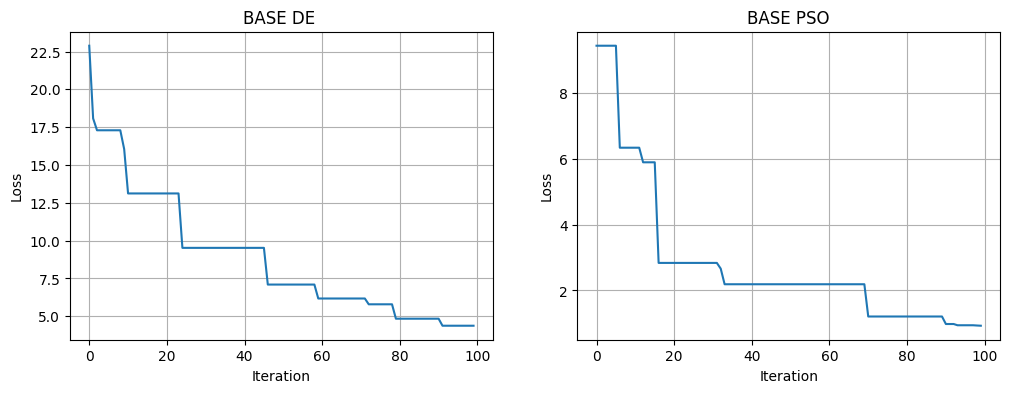

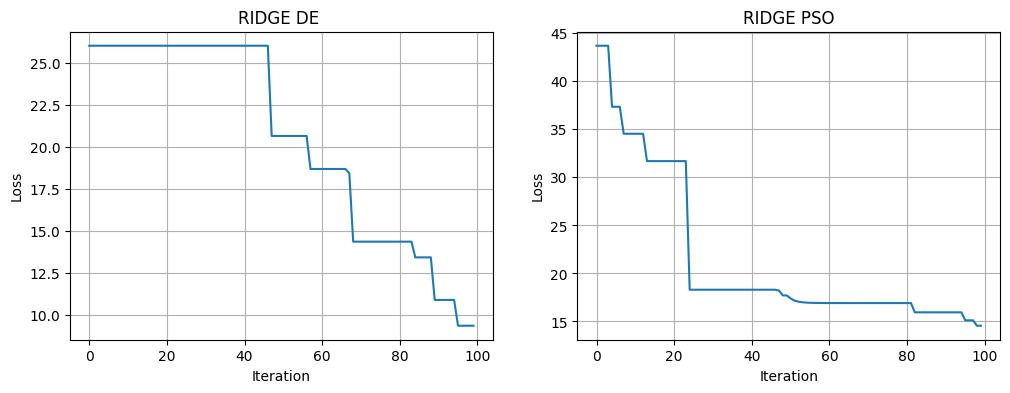

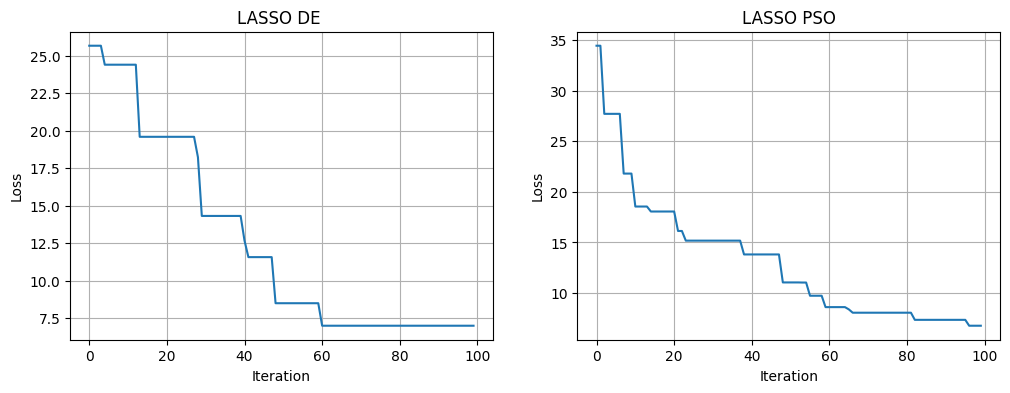

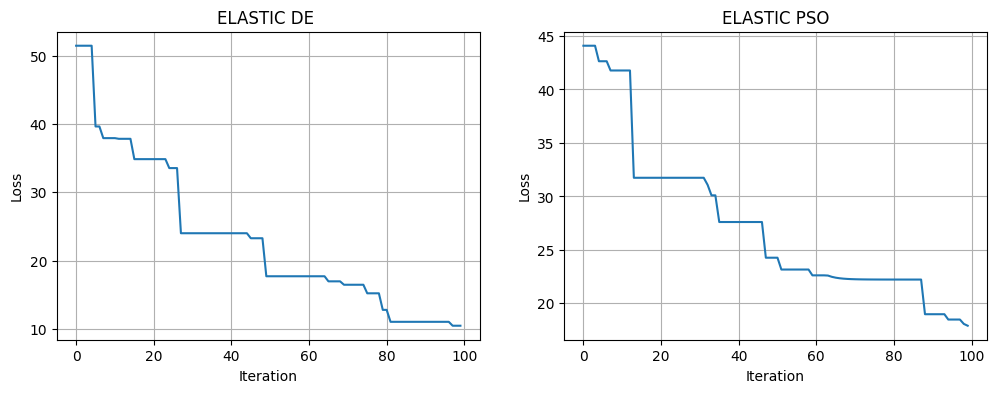

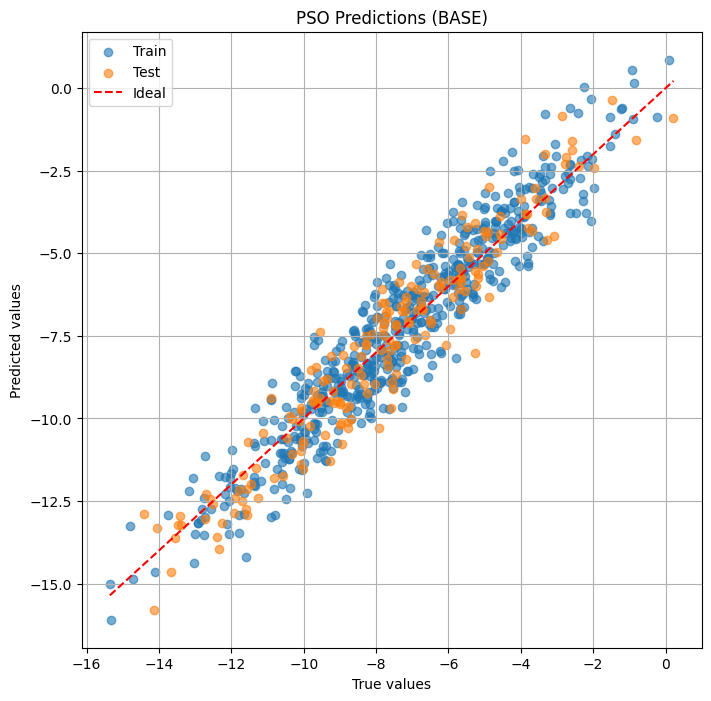

In [145]:
main("Data/TestRegDataVar9.csv")

## 2. boston_housing


BASE: 49.67854086514014 70.24093209159793

RIDGE:
Analytic: 12.281507680523102
DE: 79.93319353074654
PSO: 59.343719896585824

LASSO:
DE: 36.08008841986594
PSO: 77.08202027021605

ELASTIC:
DE: 55.41355146286549
PSO: 222.73506693402354


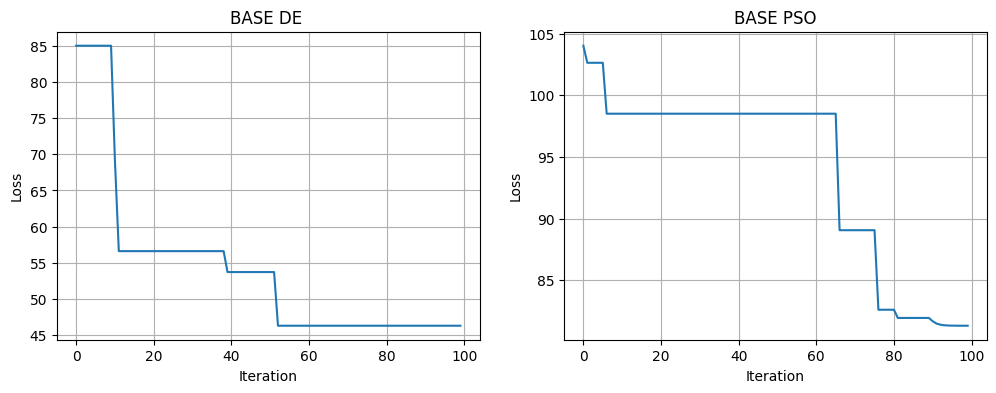

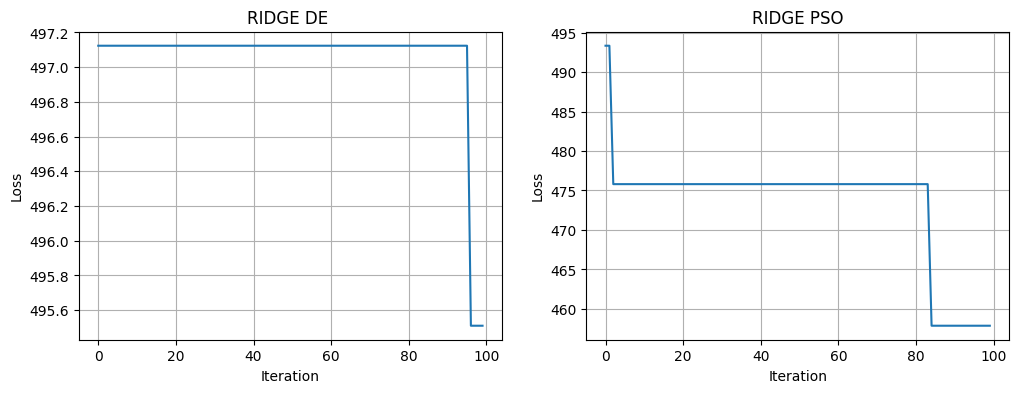

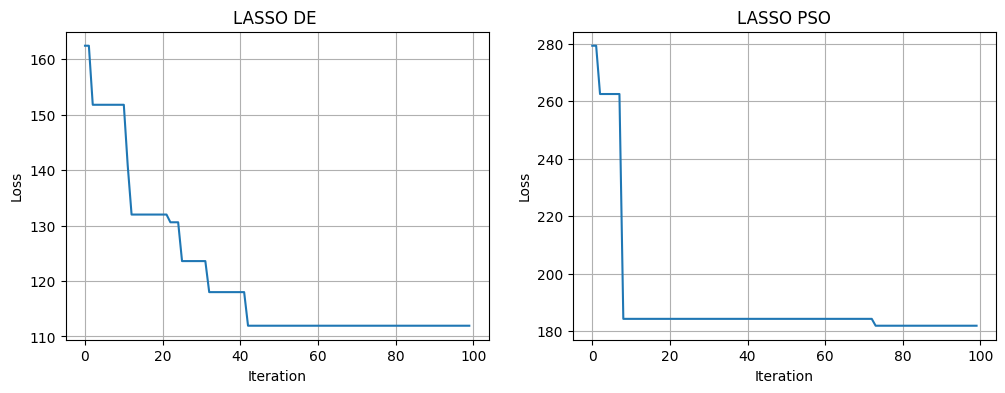

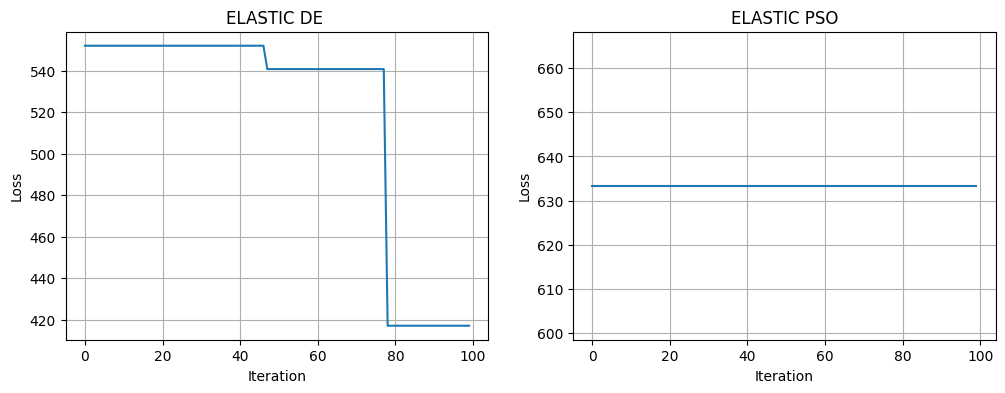

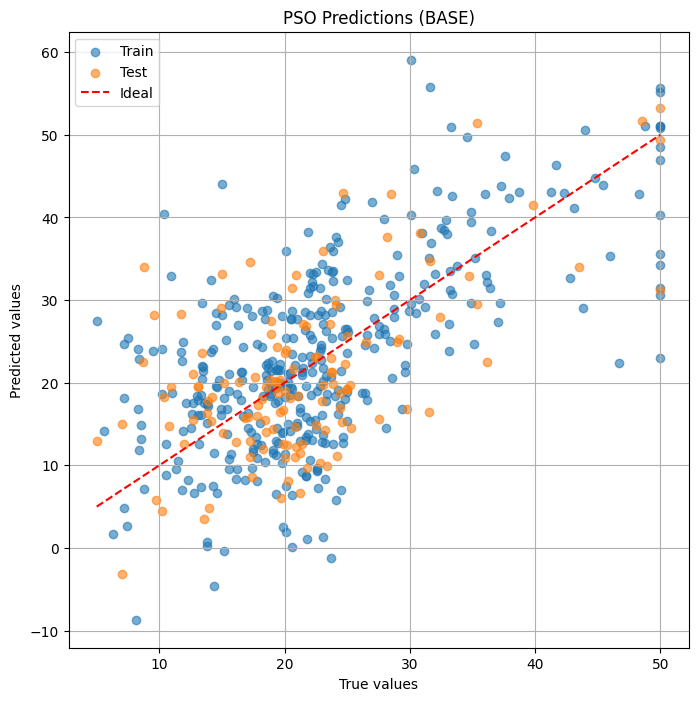

In [157]:
main("Data/boston_housing.csv")